### Plot Generation programs ###

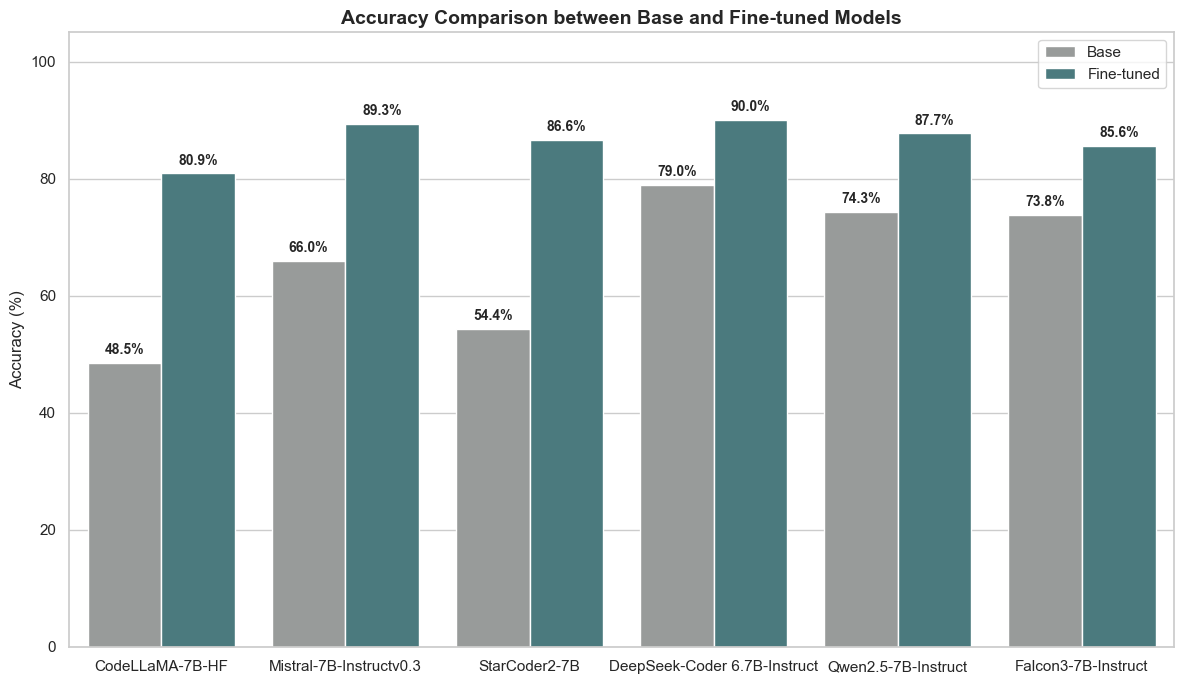

In [2]:
### Base vs fine-tuned
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV data
df = pd.read_csv("accuracy_base_fineTunedModels.csv")

# Seaborn style
sns.set(style="whitegrid")

# Plot settings
plt.figure(figsize=(12, 7))  # Increased vertical space
ax = sns.barplot(
    data=df,
    x="Model",
    y="Accuracy",
    hue="Fine-tuning Status",
    palette={"Base": "#979c9a", "Fine-tuned": "#428187"}
)

# Annotate only bars with actual height
for p in ax.patches:
    height = p.get_height()
    if height > 0.5:  # Only label bars with meaningful values
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height + 1),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# Title and labels
plt.title("Accuracy Comparison between Base and Fine-tuned Models", fontsize=14, weight='bold')
plt.ylabel("Accuracy (%)")
plt.xlabel("")  # Removes the x-axis label
plt.ylim(0, 105)  # Set Y-axis range
plt.xticks(rotation=0)
plt.legend()

# Layout and save
plt.tight_layout()
plt.savefig("fine_tuning_comparison_5models_clean.png", dpi=300)
plt.show()

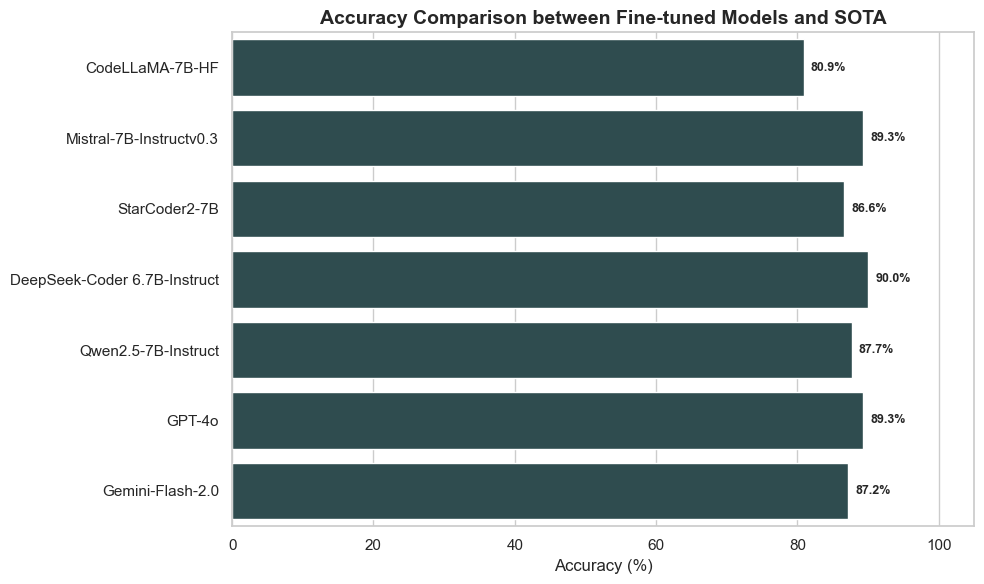

In [105]:
## Comparison between Fine-Tuned and SOTA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file (make sure it has 'Model' and 'Accuracy' columns)
file = "accuracy_fineTunedModels.csv"
df = pd.read_csv(file)

# Seaborn style
sns.set(style="whitegrid")

# Set plot size
plt.figure(figsize=(10, 6))

# Horizontal bar plot: One bar per model
ax = sns.barplot(data=df, y="Model", x="Accuracy", color="#2a5054")

# Annotate bars with accuracy values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:.1f}%",
        (width + 1, p.get_y() + p.get_height() / 2.),
        ha='left',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

# Title and labels
plt.title("Accuracy Comparison between Fine-tuned Models and SOTA", fontsize=14, weight='bold')
plt.xlabel("Accuracy (%)")
plt.ylabel("")
plt.xlim(0, 105)

# Layout and save
plt.tight_layout()
plt.savefig("final_finetuned_models_accuracy_horizontal.png", dpi=300)
plt.show()


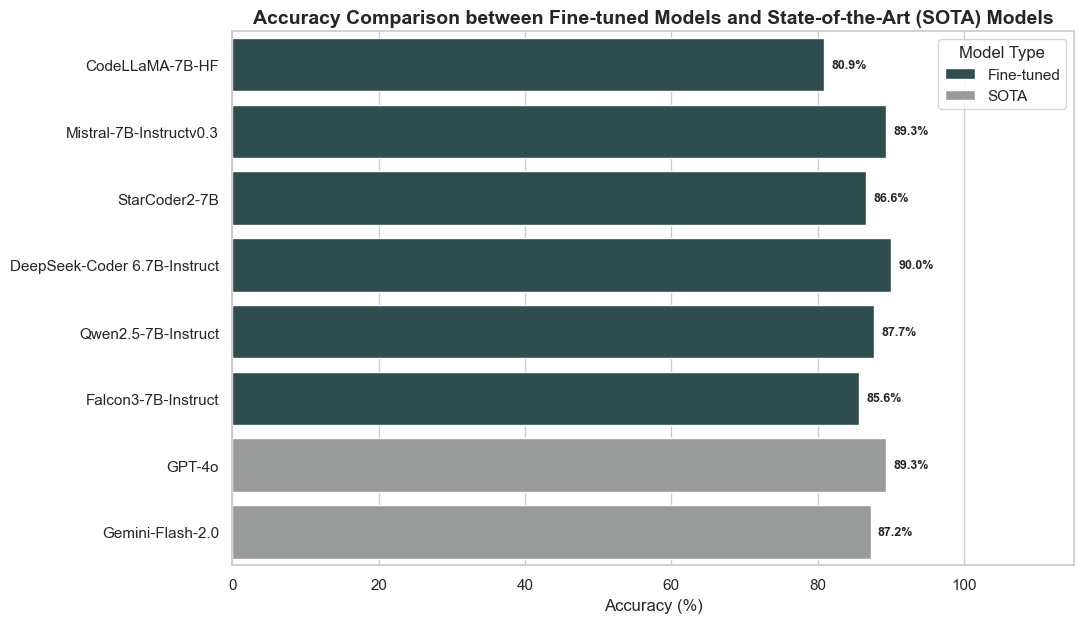

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV file (assumes 'Model' and 'Accuracy' columns)
file = "accuracy_fineTunedModels.csv"
df = pd.read_csv(file)

# Categorize models as Fine-tuned or SOTA
# Assume models with "GPT" or "Gemini" in their name are SOTA
df['Category'] = df['Model'].apply(lambda x: 'SOTA' if 'GPT' in x or 'Gemini' in x else 'Fine-tuned')

# Seaborn style
sns.set(style="whitegrid")

# Set plot size
bar_thickness = 0.8  # smaller = thinner bars
num_bars = len(df)
plt.figure(figsize=(11, bar_thickness * num_bars))

# Horizontal bar plot with different colors for Fine-tuned and SOTA
ax = sns.barplot(data=df, y="Model", x="Accuracy", hue="Category", palette={'Fine-tuned': '#2a5054', 'SOTA': '#979c9a'})

# Annotate bars with accuracy values
for p in ax.patches:
    width = p.get_width()
    if width > 0:  # Ensure annotation only for non-zero bars
        ax.annotate(
            f"{width:.1f}%",
            (width + 1, p.get_y() + p.get_height() / 2.),
            ha='left',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

# Title and labels
plt.title("Accuracy Comparison between Fine-tuned Models and State-of-the-Art (SOTA) Models", fontsize=14, weight='bold')
plt.xlabel("Accuracy (%)")
plt.ylabel("")
plt.xlim(0, 115)

# Customize legend
plt.legend(title="Model Type", loc='upper right')

# Layout and save
plt.tight_layout()
plt.savefig("Fig9.png", dpi=300)
plt.show()

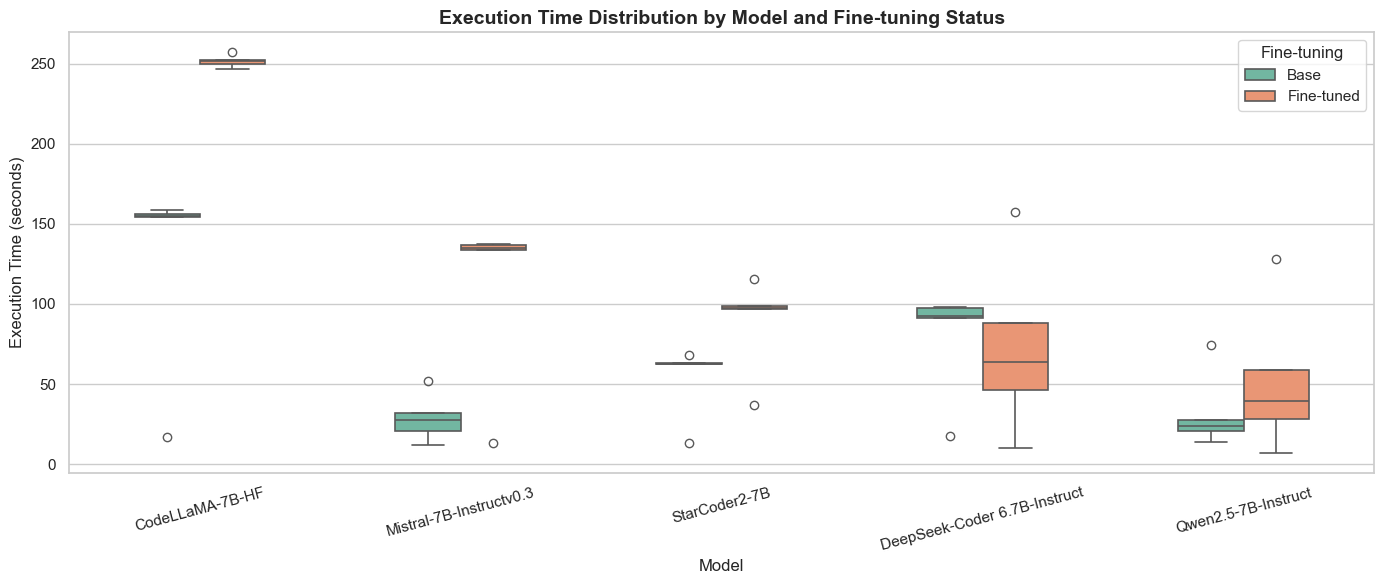

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("execution_time_base_fineTunedModels.csv")  # Your extended data with Q1/Q3/Median etc.

# Expected columns: Model, Fine-tuning Status, Q1, Q3, Min, Max, Median

# Expand data for seaborn boxplot: each row represents one data point
# Here we simulate samples between Q1–Q3, and extend to cover Min and Max as whiskers
rows = []
for _, row in df.iterrows():
    model = row["Model"]
    status = row["Fine-tuning Status"]
    label = f"{model}"
    # Generate synthetic samples from percentiles
    q1 = row['Q1']
    q3 = row['Q3']
    median = row['Median']
    min_val = row['Min']
    max_val = row['Max']
    
    # Create synthetic samples to mimic distribution shape
    samples = [min_val] + [q1] * 10 + [median] * 10 + [q3] * 10 + [max_val]
    for value in samples:
        rows.append({"Model": label, "Fine-tuning": status, "Execution Time": value})

# Create synthetic long-form dataframe
long_df = pd.DataFrame(rows)

# Plot
plt.figure(figsize=(14, 6))
sns.set(style="whitegrid")

ax = sns.boxplot(
    x="Model",
    y="Execution Time",
    hue="Fine-tuning",
    data=long_df,
    palette="Set2",
    width=0.5,
    linewidth=1.2
)

# Styling
plt.title("Execution Time Distribution by Model and Fine-tuning Status", fontsize=14, weight='bold')
plt.xlabel("Model")
plt.ylabel("Execution Time (seconds)")
plt.xticks(rotation=15)
plt.legend(title="Fine-tuning", loc="upper right")

plt.tight_layout()
plt.savefig("execution_time_grouped_boxplot.png", dpi=300)
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_376\1628049193.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=0)


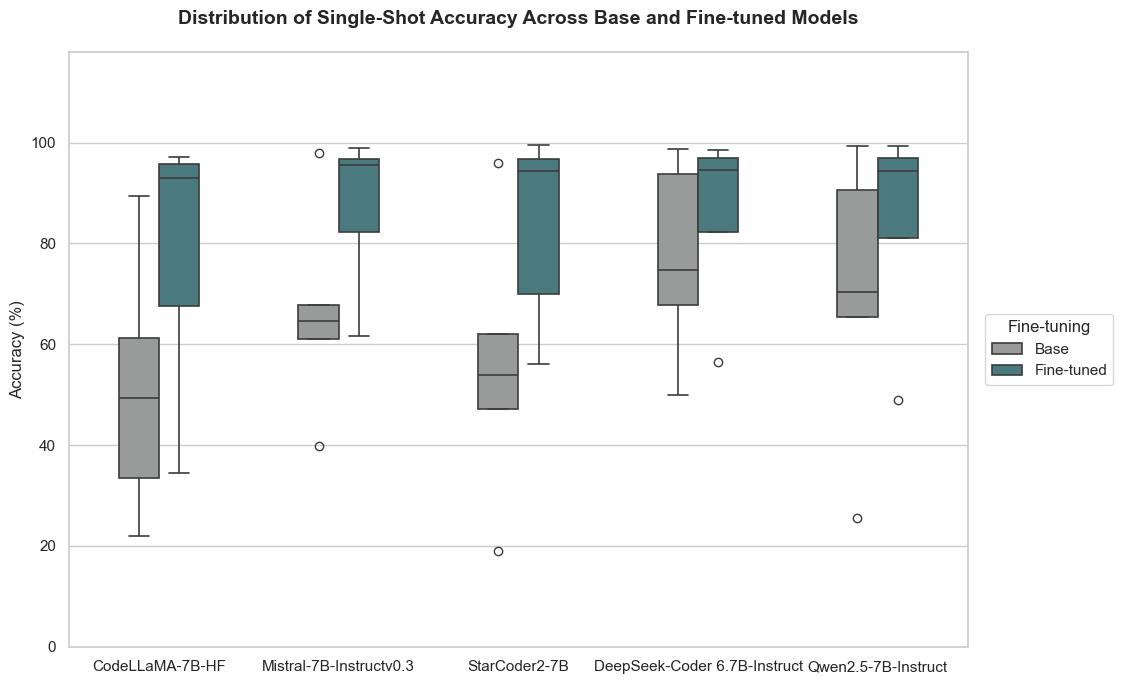

In [103]:
# Plot
plt.figure(figsize=(12, 7))
sns.set(style="whitegrid")

# Custom color palette
custom_palette = {"Base": "#979c9a", "Fine-tuned": "#428187"}

ax = sns.boxplot(
    x="Model",
    y="Execution Time",
    hue="Fine-tuning",
    data=long_df,
    palette=custom_palette,
    width=0.45,
    linewidth=1.2
)

# Title and styling
ax.set_title(
    "Distribution of Single-Shot Accuracy Across Base and Fine-tuned Models",
    fontsize=14,
    weight='bold',
    pad=20
)
ax.set_xlabel("")
ax.set_ylabel("Accuracy (%)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 118)

# Legend outside
ax.legend(title="Fine-tuning", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig("execution_time_grouped_boxplot.png", dpi=300)
plt.show()



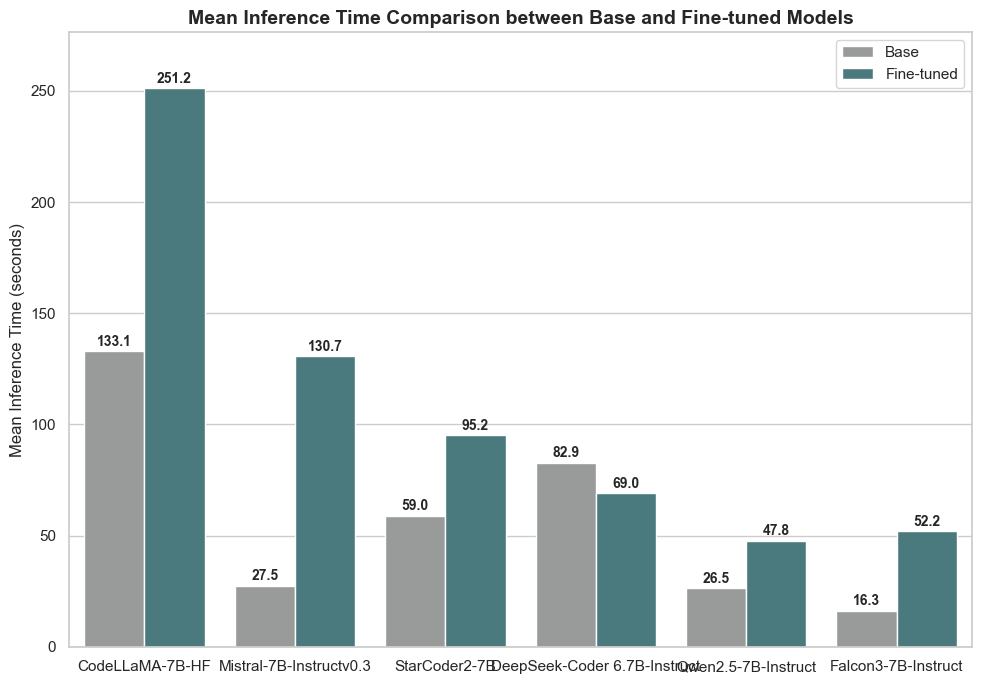

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV data
df = pd.read_csv("execution_time_base_fineTunedModels.csv")

# Seaborn style
sns.set(style="whitegrid")

# Plot settings
plt.figure(figsize=(10, 7))  # Increased vertical space
ax = sns.barplot(
    data=df,
    x="Model",
    y="Mean",
    hue="Fine-tuning Status",
    palette={"Base": "#979c9a", "Fine-tuned": "#428187"}
)

# Annotate only bars with actual height
for p in ax.patches:
    height = p.get_height()
    if height > 0.5:  # Only label bars with meaningful values
        ax.annotate(
            f"{height:.1f}",
            (p.get_x() + p.get_width() / 2., height + 1),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# Title and labels
plt.title("Mean Inference Time Comparison between Base and Fine-tuned Models", fontsize=14, weight='bold')
plt.ylabel("Mean Inference Time (seconds)")
plt.xlabel("")  # Removes the x-axis label
plt.ylim(0, max(df["Mean"]) * 1.1)  # Set y-axis range dynamically with 10% margin
plt.xticks(rotation=15)
plt.legend()

# Layout and save
plt.tight_layout()
plt.savefig("mean_execution_time_grouped_bar_chart.png", dpi=300)
plt.show()

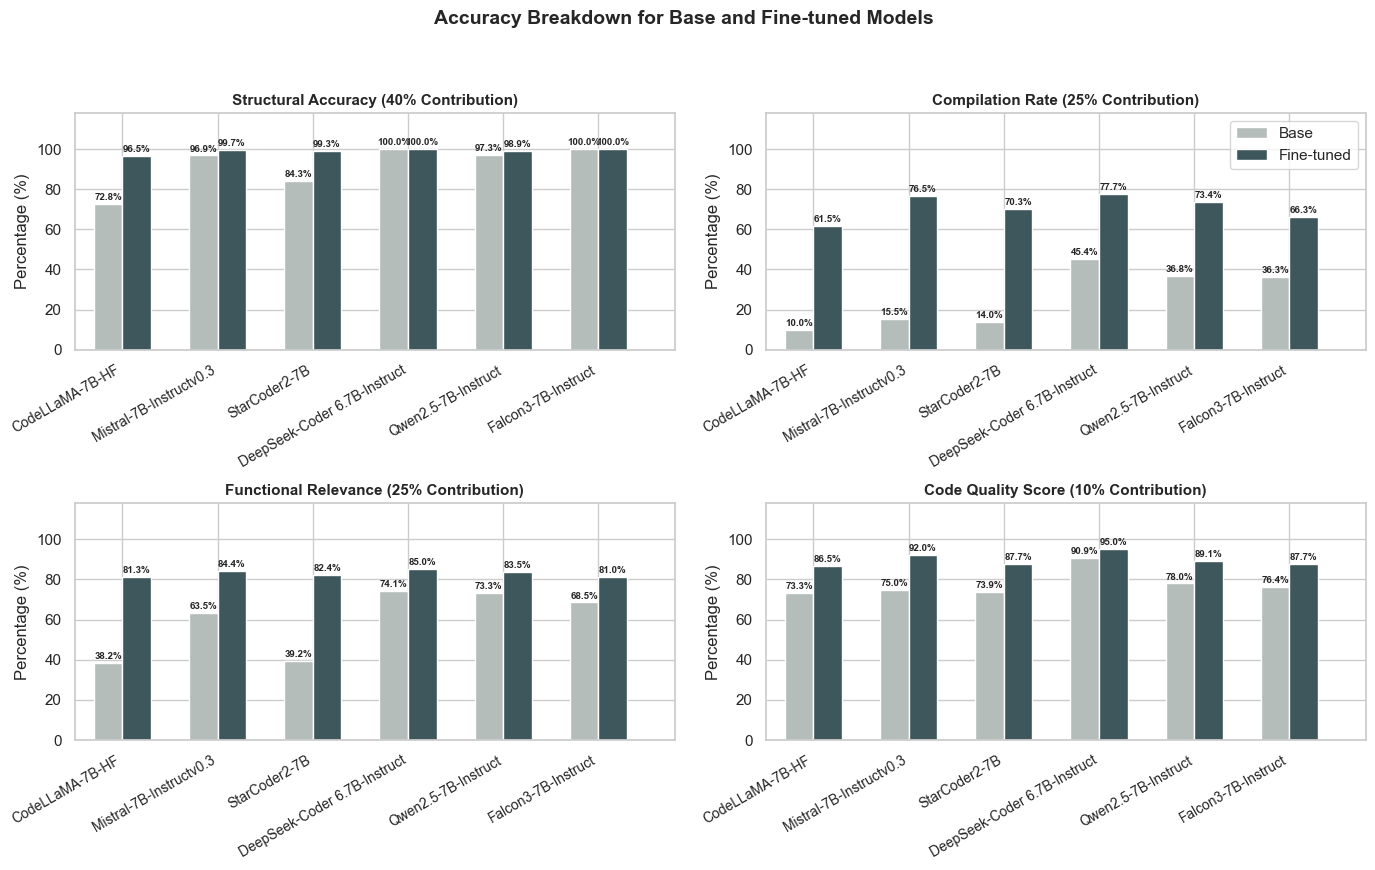

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv("accuracy_breakdown_base_fineTunedModels.csv")

# Normalize each metric column
df["Structural Validation (%)"] = df["Structural Validation"] / 40 * 100
df["Compilation Success (%)"] = df["Compilation Success"] / 25 * 100
df["Functional Relevance (%)"] = df["Functional  Relevance"] / 25 * 100
df["Code Quality Analysis (%)"] = df["Code Quality Analysis"] / 10 * 100

# Metrics to plot
metrics = [
    "Structural Validation (%)",
    "Compilation Success (%)",
    "Functional Relevance (%)",
    "Code Quality Analysis (%)"
]

# Custom titles for each subplot (Approach 1)
custom_titles = [
    "Structural Accuracy (40% Contribution)",
    "Compilation Rate (25% Contribution)",
    "Functional Relevance (25% Contribution)",
    "Code Quality Score (10% Contribution)"
]
# Extract model labels (Base only to avoid duplicates)
base_models = df[df["Fine-tuning Status"] == "Base"]["Model"].values
x = np.linspace(0, len(base_models) - 1, len(base_models))  # Compact spacing
bar_width = 0.30

# Plot setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Colors
base_color = '#b5bdba'
fine_color = '#3e575c'

# Plot each metric
for i, metric in enumerate(metrics):
    ax = axes[i]

    base_vals = df[df["Fine-tuning Status"] == "Base"][metric].values
    fine_vals = df[df["Fine-tuning Status"] == "Fine-tuned"][metric].values

    bars_base = ax.bar(x - bar_width/2, base_vals, width=bar_width, label="Base", color=base_color)
    bars_fine = ax.bar(x + bar_width/2, fine_vals, width=bar_width, label="Fine-tuned", color=fine_color)

    # Set custom title (Approach 1: Using custom_titles list)
    ax.set_title(custom_titles[i], fontsize=11, weight='bold')
    #ax.set_title(metric, fontsize=11, weight='bold')
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim(0, 118)
    ax.set_xticks(x)
    ax.set_xticklabels(base_models, rotation=30, ha='right', fontsize=10)
    # Adjusted x-axis limits to ensure last bars are fully visible
    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5 + bar_width)

    # Annotate bars
    for bar in bars_base:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}%", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7, weight='bold')
    for bar in bars_fine:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}%", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7, weight='bold')

    if i == 1:  # Add legend to top-right subplot
        ax.legend()

# Final layout adjustments
plt.suptitle("Accuracy Breakdown for Base and Fine-tuned Models", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(bottom=0.25, hspace=0.65)  # Increased vertical spacing between rows
plt.savefig("accuracy_breakdown_grouped_subplot.png", dpi=300)
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_376\1377476530.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


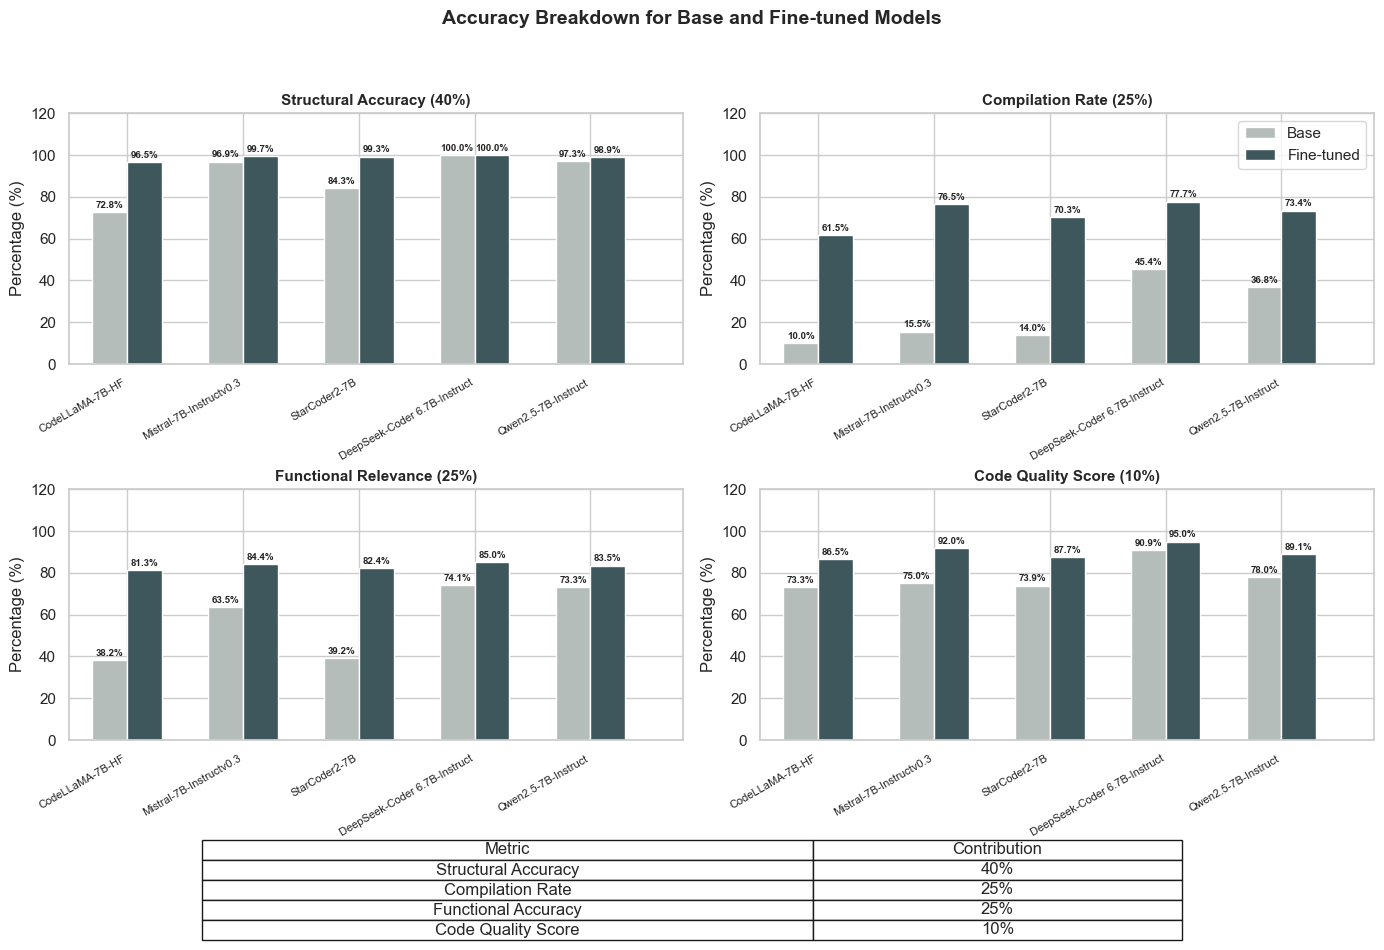

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import table

# Load CSV
df = pd.read_csv("accuracy_breakdown_base_fineTunedModels.csv")

# Normalize each metric column
df["Structural Validation (%)"] = df["Structural Validation"] / 40 * 100
df["Compilation Success (%)"] = df["Compilation Success"] / 25 * 100
df["Functional Relevance (%)"] = df["Functional  Relevance"] / 25 * 100
df["Code Quality Analysis (%)"] = df["Code Quality Analysis"] / 10 * 100

# Metrics to plot
metrics = [
    "Structural Validation (%)",
    "Compilation Success (%)",
    "Functional Relevance (%)",
    "Code Quality Analysis (%)"
]

# Simplified custom titles for each subplot
custom_titles = [
    "Structural Accuracy (40%)",
    "Compilation Rate (25%)",
    "Functional Relevance (25%)",
    "Code Quality Score (10%)"
]

# Extract model labels (Base only to avoid duplicates)
base_models = df[df["Fine-tuning Status"] == "Base"]["Model"].values
x = np.linspace(0, len(base_models) - 1, len(base_models))  # Compact spacing
bar_width = 0.30

# Plot setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Colors
base_color = '#b5bdba'
fine_color = '#3e575c'

# Plot each metric
for i, metric in enumerate(metrics):
    ax = axes[i]

    base_vals = df[df["Fine-tuning Status"] == "Base"][metric].values
    fine_vals = df[df["Fine-tuning Status"] == "Fine-tuned"][metric].values

    bars_base = ax.bar(x - bar_width/2, base_vals, width=bar_width, label="Base", color=base_color)
    bars_fine = ax.bar(x + bar_width/2, fine_vals, width=bar_width, label="Fine-tuned", color=fine_color)

    # Set simplified custom title
    ax.set_title(custom_titles[i], fontsize=11, weight='bold')
    ax.set_ylabel("Percentage (%)")
    ax.set_ylim(0, 120)
    ax.set_xticks(x)
    ax.set_xticklabels(base_models, rotation=30, ha='right', fontsize=8)
    # Adjusted x-axis limits to ensure last bars are fully visible
    ax.set_xlim(x[0] - 0.5, x[-1] + 0.5 + bar_width)

    # Annotate bars
    for bar in bars_base:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}%", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7, weight='bold')
    for bar in bars_fine:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}%", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7, weight='bold')

    if i == 1:  # Add legend to top-right subplot
        ax.legend()

# Optional: Add a table for contributions (uncomment to use)

# Create a table with contributions
table_data = [
    ["Metric", "Contribution"],
    ["Structural Accuracy", "40%"],
    ["Compilation Rate", "25%"],
    ["Functional Accuracy", "25%"],
    ["Code Quality Score", "10%"]
]
table_ax = fig.add_axes([0.15, 0.05, 0.7, 0.1])  # [left, bottom, width, height]
table_ax.axis('off')
tbl = table.Table(table_ax, bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
for (row, col), val in np.ndenumerate(table_data):
    tbl.add_cell(row, col, 1, 1, text=val, loc='center')
tbl.auto_set_column_width([0, 1])
table_ax.add_table(tbl)


# Final layout adjustments
plt.suptitle("Accuracy Breakdown for Base and Fine-tuned Models", fontsize=14, weight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.subplots_adjust(bottom=0.25, hspace=0.5)  # Increased vertical spacing between rows
plt.savefig("accuracy_breakdown_grouped_subplot.png", dpi=300)
plt.show()